# LightGBM

In [1]:
# Install LightGBM if needed
# !pip install lightgbm -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from lightgbm import LGBMClassifier, LGBMRegressor


## Part A: LightGBM Classification

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

clf = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report")
print(classification_report(y_test, pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000478 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,Feature,Importance
21,worst texture,507
27,worst concave points,498
28,worst symmetry,283
22,worst perimeter,255
7,mean concave points,238
1,mean texture,235
13,area error,227
20,worst radius,206
24,worst smoothness,182
23,worst area,174


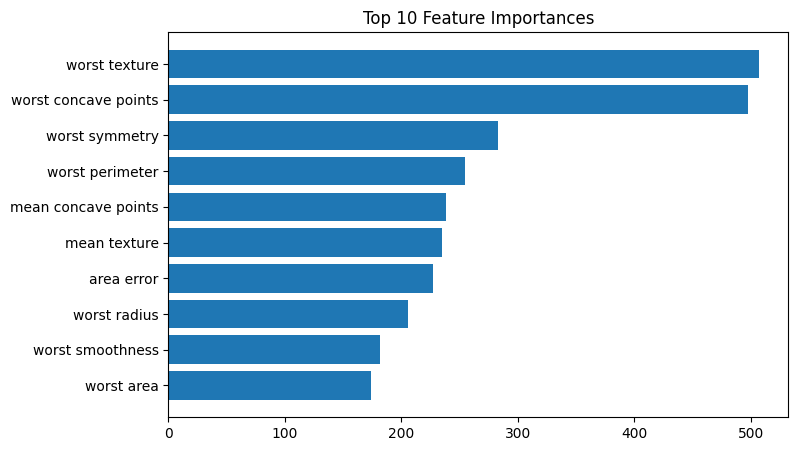

In [3]:
fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": clf.feature_importances_
}).sort_values("Importance", ascending=False)

display(fi.head(10))

plt.figure(figsize=(8,5))
plt.barh(fi.head(10)["Feature"], fi.head(10)["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances")
plt.show()


## Part B: LightGBM Regression

In [4]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

reg = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

reg.fit(X_train, y_train)

pred = reg.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2  :", r2_score(y_test, pred))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003421 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
MAE : 0.29657576217534676
RMSE: 0.44980992465907704
R2  : 0.8455986095322606


,Feature,Importance
7,Longitude,1855
6,Latitude,1845
5,AveOccup,1186
0,MedInc,1151
2,AveRooms,828
4,Population,743
1,HouseAge,736
3,AveBedrms,656


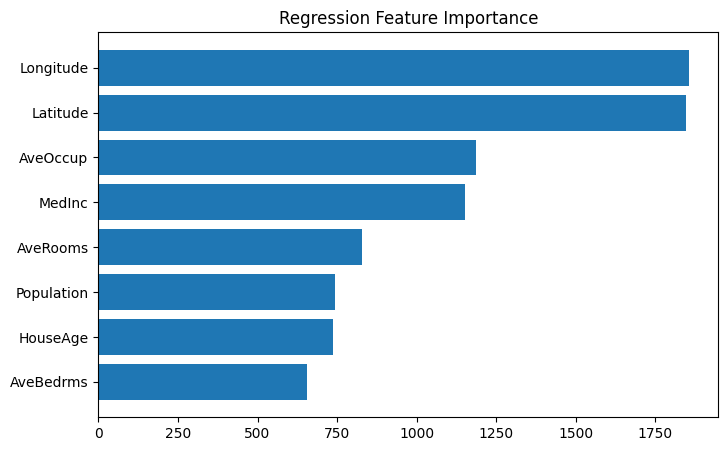

In [5]:
fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": reg.feature_importances_
}).sort_values("Importance", ascending=False)

display(fi)

plt.figure(figsize=(8,5))
plt.barh(fi["Feature"], fi["Importance"])
plt.gca().invert_yaxis()
plt.title("Regression Feature Importance")
plt.show()


## Exercises
1. Change `learning_rate` and compare performance.
2. Increase/decrease `n_estimators`.
3. Apply cross-validation.
4. Tune parameters using GridSearchCV or RandomizedSearchCV.
5. Compare LightGBM with Random Forest and XGBoost.


## For more reference:

1. Unfold Data Science: https://youtu.be/9uxWzeLglr0
2. This Technology Life: https://youtu.be/A2Xf8YgFdko
3. EduMentor Dipti: https://youtu.be/-qU97khcQUo
4. DigitalSreeni: https://youtu.be/n_ZMQj09S6w
5. meanxai: https://youtu.be/N39NE4Nj6vc
6. meanxai: https://youtu.be/APZyWo9hIj0
7. meanxai: https://youtu.be/Y-IvfsjmqOQ
8. meanxai: https://youtu.be/orSRRtWtPwE
9. meanxai: https://youtu.be/NqpkYja5g2Y